Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset loaded successfully!
Initial shape: (9471, 17)
         Date      Time CO(GT)  PT08.S1(CO)  NMHC(GT) C6H6(GT)  PT08.S2(NMHC)  \
0  10/03/2004  18.00.00    2,6       1360.0     150.0     11,9         1046.0   
1  10/03/2004  19.00.00      2       1292.0     112.0      9,4          955.0   
2  10/03/2004  20.00.00    2,2       1402.0      88.0      9,0          939.0   

   NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH  \
0    166.0        1056.0    113.0        1692.0       1268.0  13,6  48,9   
1    103.0        1174.0     92.0        1559.0        972.0  13,3  47,7   
2    131.0        1140.0    114.0        1555.0       1074.0  11,9  54,0   

       AH  Unnamed: 15  Unnamed: 16  
0  0,7578          NaN          NaN  
1  0,7255          NaN          NaN  
2  0,7502          NaN          NaN  
✅ Cleaned shape: (9357, 8)
🎯 Usi

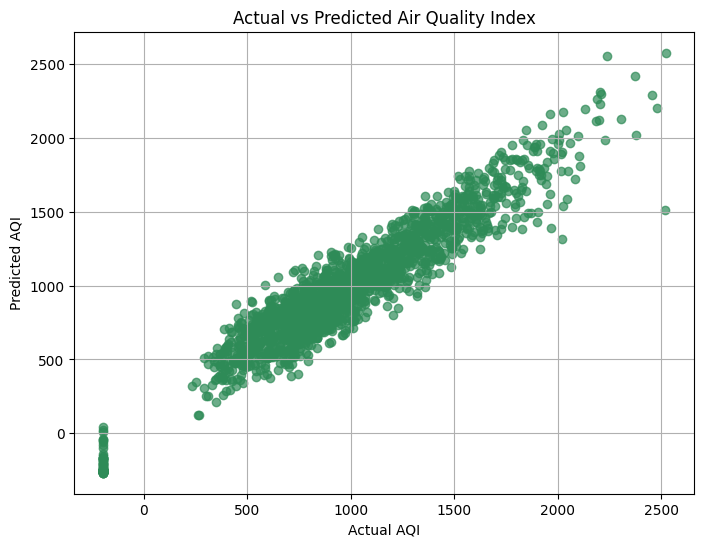


🔥 Top 10 Important Features:
         Feature  Importance
0    PT08.S1(CO)    0.841403
2  PT08.S2(NMHC)    0.559907
5        NO2(GT)    0.333918
3        NOx(GT)    0.291406
4   PT08.S3(NOx)    0.232496
6   PT08.S4(NO2)    0.142454
1       NMHC(GT)    0.021951


In [2]:
# ===========================================================
# 🌿 AIR QUALITY INDEX PREDICTION PROJECT (FOML MINI PROJECT)
# ===========================================================

# STEP 1️⃣ – Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# STEP 2️⃣ – Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ✅ STEP 3️⃣ – Correct path to your dataset
path = "/content/drive/MyDrive/machine learning/AirQuality.csv"  # ensure exact filename!

# STEP 4️⃣ – Load dataset safely (semicolon or comma separated)
try:
    df = pd.read_csv(path, sep=';', engine='python')
except:
    df = pd.read_csv(path)

print("✅ Dataset loaded successfully!")
print("Initial shape:", df.shape)
print(df.head(3))

# STEP 5️⃣ – Clean dataset
df.columns = df.columns.str.strip().str.replace(';', '').str.replace(' ', '_')
df.replace(['?', '---', 'NaN', 'n/a', 'NA'], np.nan, inplace=True)
df = df.dropna(how='all', axis=1)  # Drop empty columns

# Drop non-numeric columns if they exist
non_numeric = [col for col in df.columns if df[col].dtype == 'object']
df = df.drop(columns=non_numeric, errors='ignore')

# Convert everything to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Drop rows that are entirely NaN or partially NaN
df = df.dropna()
print("✅ Cleaned shape:", df.shape)

# STEP 6️⃣ – Check for valid samples
if df.shape[0] == 0:
    raise ValueError("❌ Dataset became empty after cleaning! Check if your CSV has valid numeric values.")

# STEP 7️⃣ – Identify target column (AQI or fallback)
target_col = None
for col in df.columns:
    if 'AQI' in col.upper():
        target_col = col
        break

if target_col is None:
    target_col = df.columns[-1]  # use last column as target if AQI not found

print(f"🎯 Using target column: {target_col}")

# STEP 8️⃣ – Split dataset
X = df.drop(columns=[target_col])
y = df[target_col]

# Ensure we have at least 2 unique rows
if len(X) < 2:
    raise ValueError("❌ Not enough samples after cleaning. Try reducing data cleaning or verify dataset content.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 9️⃣ – Train Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# STEP 🔟 – Evaluate model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n📊 MODEL PERFORMANCE")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# STEP 11️⃣ – Visualization
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='seagreen')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted Air Quality Index")
plt.grid(True)
plt.show()

# STEP 12️⃣ – Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(lr.coef_)
}).sort_values(by='Importance', ascending=False)

print("\n🔥 Top 10 Important Features:")
print(importance.head(10))
